 ### GUV 自动分析脚本 (全数据保存 + 质量检测版)

In [1]:
# in this *_53version, try to use percentile rather than mean to calculate the backgound, since another GUV drifting into a corner or a piece of debris will significantly interfere the calculation for by using the simple 4-corner sampling

In [2]:
%matplotlib inline  
# 在 Jupyter Notebook 中直接显示图表
import cv2 # OpenCV 库，用于图像处理（如绘制圆形掩模）
import numpy as np  # 用于数值计算，处理数组
import pandas as pd # 用于数据处理和保存 CSV
import pims # 专门用于读取生物学图像序列（TIF 堆栈）的库
import os # 处理文件路径和目录
import glob # 用于匹配特定模式的文件名（如找所有 .tif 文件）
from matplotlib import pyplot as plt # 绘图库

# 设置全局绘图样式
plt.rcParams['figure.figsize'] = [10, 6] # 设置默认图片大小


In [3]:
class GUVAnalyzer:
    def __init__(self, movie_path, centers_path, vesicle_id, folder='./', correction=[0, 0]):
        self.movie_path = os.path.join(folder, movie_path)
        self.movie_name = os.path.basename(movie_path)
        self.vesicle_id = vesicle_id
        self.folder = folder 
        
        self.df_centers = pd.read_csv(os.path.join(folder, centers_path))
        self.all_frames = pims.TiffStack_pil(self.movie_path)
        
        # 拆分通道
        self.ch0 = self.all_frames[slice(0, len(self.all_frames), 2)] # 膜信号
        self.ch1 = self.all_frames[slice(1, len(self.all_frames), 2)] # 载物信号
        
        target = self.df_centers[self.df_centers['id'] == vesicle_id]
        if target.empty:
            raise ValueError(f"Vesicle ID {vesicle_id} not found")
            
        x_raw = target['x'].values[0]
        y_raw = target['y'].values[0]
        self.center0px = np.array([x_raw + correction[0], y_raw + correction[1]]).astype(int)
        
        self.circles_per_frame = []
        self.results_df = None

    def _get_profiles(self, center, img, margin):
        h, w = img.shape
        x_start, x_end = max(0, center[0]-margin), min(w, center[0]+margin)
        y_start, y_end = max(0, center[1]-margin), min(h, center[1]+margin)
        x_arr = np.average(img[:, x_start:x_end], axis=1)
        y_arr = np.average(img[y_start:y_end, :], axis=0)
        return x_arr, y_arr

    def _calc_threshold(self, center, img, margin=5, corner_size=30):
        """核心改进：使用四个顶角计算背景"""
        h, w = img.shape
        # 内部采样：中心 5x5 区域
        inside = np.average(img[max(0,center[1]-margin):min(h,center[1]+margin), 
                                max(0,center[0]-margin):min(w,center[0]+margin)])
        
        # 外部背景：四个顶角 30x30 区域均值
        c1 = img[0:corner_size, 0:corner_size]                # 左上
        c2 = img[0:corner_size, w-corner_size:w]              # 右上
        c3 = img[h-corner_size:h, 0:corner_size]              # 左下
        c4 = img[h-corner_size:h, w-corner_size:w]            # 右下
        all_bg_pixels = np.concatenate([c1, c2, c3, c4])
        # 3. 【核心优化】：取全采样区 10% 分位数
        # 逻辑：即便 4 个角中有 2 个全亮，只要剩下 2 个角（约50%像素）里有暗区，
        # 10% 分位数就能准确代表最暗的背景值。
        background = np.percentile(all_bg_pixels, 30)

        if inside > background * 1.5:
            thresh = 2 * inside
        else:
            thresh = inside + (background - inside) / 2
        return thresh, inside, background

    def _compute_circle(self, img, thresh_val, current_center, avg_size=15):
        x_arr, y_arr = self._get_profiles(current_center, img, avg_size) 
        left_search = x_arr[0:current_center[1]] 
        x_idx_l = np.nonzero(left_search > thresh_val)[0][-1] if np.any(left_search > thresh_val) else 0 
        right_search = x_arr[current_center[1]:]
        x_idx_r = current_center[1] + (np.nonzero(right_search > thresh_val)[0][0] if np.any(right_search > thresh_val) else len(right_search))
        
        left_y_search = y_arr[0:current_center[0]]
        y_idx_l = np.nonzero(left_y_search > thresh_val)[0][-1] if np.any(left_y_search > thresh_val) else 0
        right_y_search = y_arr[current_center[0]:]
        y_idx_r = current_center[0] + (np.nonzero(right_y_search > thresh_val)[0][0] if np.any(right_y_search > thresh_val) else len(right_y_search))
        
        x_dist, y_dist = (x_idx_r - x_idx_l), (y_idx_r - y_idx_l)
        cx, cy = y_idx_l + int(y_dist/2), x_idx_l + int(x_dist/2)
        r = 1.1 * max(x_dist, y_dist) / 2
        return cx, cy, r

    def run_tracking(self):
        active_center = self.center0px
        for frame in self.ch1:
            t_val, _, _ = self._calc_threshold(active_center, frame)
            try:
                cx, cy, r = self._compute_circle(frame, t_val, active_center)
                self.circles_per_frame.append([cx, cy, r])
                active_center = np.array([cx, cy]).astype(int)
            except:
                self.circles_per_frame.append(None)
    
    def save_diagnostics(self):
        """可视化：显示四个顶角的红色背景采样区和中心的蓝色采样区"""
        import matplotlib.patches as patches
        diag_dir = os.path.join(self.folder, f"DIAG_{os.path.splitext(self.movie_name)[0]}_V{self.vesicle_id}")
        if not os.path.exists(diag_dir): os.makedirs(diag_dir)
            
        for i, frame in enumerate(self.ch1):
            circ = self.circles_per_frame[i]
            h, w = frame.shape
            cs = 30 # corner_size
            
            fig, ax = plt.subplots(1, 2, figsize=(15, 7))
            ax[0].imshow(frame, cmap='gray')
            ax[0].set_title(f"Frame {i} - Track & 4-Corner BG")
            
            # 绘制四个顶角背景区 (红色虚线)
            corners = [(0,0), (w-cs, 0), (0, h-cs), (w-cs, h-cs)]
            for coord in corners:
                ax[0].add_patch(patches.Rectangle(coord, cs, cs, linewidth=2, 
                                                edgecolor='red', facecolor='none', linestyle='--', zorder=10))

            if circ is not None:
                cx, cy, r = circ
                # 绘制内部采样区 (蓝色框)
                im = 5 # inner_margin
                ax[0].add_patch(patches.Rectangle((cx-im, cy-im), im*2, im*2, 
                                                linewidth=2, edgecolor='cyan', facecolor='none', zorder=10))
                # 绘制追踪圆 (绿色)
                ax[0].add_patch(plt.Circle((cx, cy), r, color='lime', fill=False, linewidth=2))
                ax[0].scatter([cx], [cy], color='red', s=20)

                # 右图：Mask 验证
                t_val, in_val, bg_val = self._calc_threshold([int(cx), int(cy)], frame)
                ax[1].imshow(frame > t_val, cmap='viridis')
                ax[1].set_title(f"Thresh: {t_val:.1f} (In: {in_val:.1f}, BG: {bg_val:.1f})")
            
            plt.tight_layout()
            plt.savefig(os.path.join(diag_dir, f"check_f{i:04d}.png"))
            plt.close(fig) # 必须显式关闭当前画布
        plt.close('all')   # 保险起见，清理所有残留画布

    def calculate_intensities(self, circle_thickness=12, corner_size=30):
        """核心改进：最终强度计算也使用四个顶角去背景"""
        data = []
        cs = corner_size
        for i in range(len(self.ch0)):
            circ = self.circles_per_frame[i]
            f0, f1 = self.ch0[i], self.ch1[i]
            # 计算两通道四个顶角的背景均值
            h, w = f0.shape
        
        # --- 核心改进：使用 np.percentile 10% 替代 np.mean ---
        # 提取四个角的像素并合并
            def get_robust_bg(img):
                c1 = img[0:cs, 0:cs].flatten()
                c2 = img[0:cs, w-cs:w].flatten()
                c3 = img[h-cs:h, 0:cs].flatten()
                c4 = img[h-cs:h, w-cs:w].flatten()
                all_pixels = np.concatenate([c1, c2, c3, c4])
                return np.percentile(all_pixels, 30)
            bg0 = get_robust_bg(f0)
            bg1 = get_robust_bg(f1)
            
            if circ is not None:
                cx, cy, r = circ
                mask = np.zeros(f0.shape, dtype=np.uint8)
                cv2.circle(mask, (int(cx), int(cy)), int(r), 255, circle_thickness)
                coords = np.where(mask == 255) 
                int0 = np.round(np.mean(f0[coords]), 2) if len(coords[0]) > 0 else 0
                int1 = np.round(np.mean(f1[coords]), 2) if len(coords[0]) > 0 else 0
                data.append([i, self.vesicle_id, self.movie_name, int0, int1, cx, cy, r, bg0, bg1])
            else:
                data.append([i, self.vesicle_id, self.movie_name, None, None, None, None, None, bg0, bg1])
                
        cols = ['FrameId', 'VesicleId', 'MovieName', 'IntCh0', 'IntCh1', 'xCoord', 'yCoord', 'radius', 'bg0', 'bg1']
        df = pd.DataFrame(data, columns=cols)
        df['Net0'] = df['IntCh0'] - df['bg0']
        df['Net1'] = df['IntCh1'] - df['bg1']
        self.results_df = df
        return df

In [4]:
INPUT_FOLDER = './Split_By_Python_2Channel_Slices/'      ## 设定输入路径
#INPUT_FOLDER = './test/'   
movie_files = glob.glob(os.path.join(INPUT_FOLDER, "*.tif"))  ## 获取所有 .tif 文件
all_results = [] 

# 创建保存结果的文件夹
result_csv_dir = os.path.join(INPUT_FOLDER, "Individual_CSVs")
if not os.path.exists(result_csv_dir): os.makedirs(result_csv_dir)

## 循环处理每个视频
for movie_path in movie_files:
    movie_name = os.path.basename(movie_path)
    centers_path = os.path.splitext(movie_name)[0] + ".csv"
    if not os.path.exists(os.path.join(INPUT_FOLDER, centers_path)): continue

    df_centers = pd.read_csv(os.path.join(INPUT_FOLDER, centers_path))
    # 新增：剔除 id 列为空的行
    df_centers = df_centers.dropna(subset=['id'])   
    for v_id in df_centers['id'].unique():  # 循环处理视频中的每个脂质体
        try:
            guv = GUVAnalyzer(movie_name, centers_path, v_id, folder=INPUT_FOLDER)
            guv.run_tracking() # 1. 运行追踪
            
            # 1. 保存质量检测图片
            guv.save_diagnostics() 
            
            # 2. 计算强度并归一化
            df = guv.calculate_intensities(circle_thickness=12)
            f0_net0 = df.loc[0, 'Net0']
            f0_net1 = df.loc[0, 'Net1']
            df['Norm0'] = df['Net0'] / f0_net0 if f0_net0 != 0 else 0
            df['Norm1'] = df['Net1'] / f0_net1 if f0_net1 != 0 else 0
            
            # 3. 保存该囊泡的完整 CSV (包含 x, y, r, bg, norm 等)
            csv_name = f"Data_{os.path.splitext(movie_name)[0]}_V{v_id}.csv"
            df.to_csv(os.path.join(result_csv_dir, csv_name), index=False)
            
            all_results.append(df)
            print(f"Done: {movie_name} - ID {v_id}")
            
            # 及时手动清理 guv 对象释放内存
            del guv

        except Exception as e:
            print(f"Error ID {v_id}: {e}")

# 4. 保存汇总总表
master_df = pd.concat(all_results, ignore_index=True)
master_df.to_csv(os.path.join(INPUT_FOLDER, "Master_Results_All_Vesicles.csv"), index=False)


Done: 2ch_180246_001_pos001.tif - ID 4.0
Done: 2ch_180246_001_pos001.tif - ID 6.0
Done: 2ch_180246_001_pos002.tif - ID 23
Done: 2ch_180246_001_pos002.tif - ID 24
Done: 2ch_180246_001_pos002.tif - ID 25
Done: 2ch_180246_001_pos003.tif - ID 41.0
Done: 2ch_180246_001_pos003.tif - ID 42.0
Done: 2ch_180246_001_pos003.tif - ID 46.0
Done: 2ch_180246_001_pos004.tif - ID 49.0
Done: 2ch_180246_001_pos004.tif - ID 50.0
Done: 2ch_180246_001_pos004.tif - ID 51.0
Done: 2ch_180246_001_pos004.tif - ID 53.0
Done: 2ch_180246_001_pos005.tif - ID 61
Done: 2ch_180246_001_pos005.tif - ID 62
Done: 2ch_180246_001_pos005.tif - ID 63
Done: 2ch_180246_001_pos005.tif - ID 64
Done: 2ch_180246_001_pos006.tif - ID 66
Done: 2ch_180246_001_pos006.tif - ID 67
Done: 2ch_180246_001_pos006.tif - ID 68
Done: 2ch_180246_001_pos007.tif - ID 77
Done: 2ch_180246_001_pos007.tif - ID 78
Done: 2ch_180246_001_pos008.tif - ID 84
Done: 2ch_180246_001_pos008.tif - ID 85
Done: 2ch_180246_001_pos008.tif - ID 86
Done: 2ch_180246_001_pos

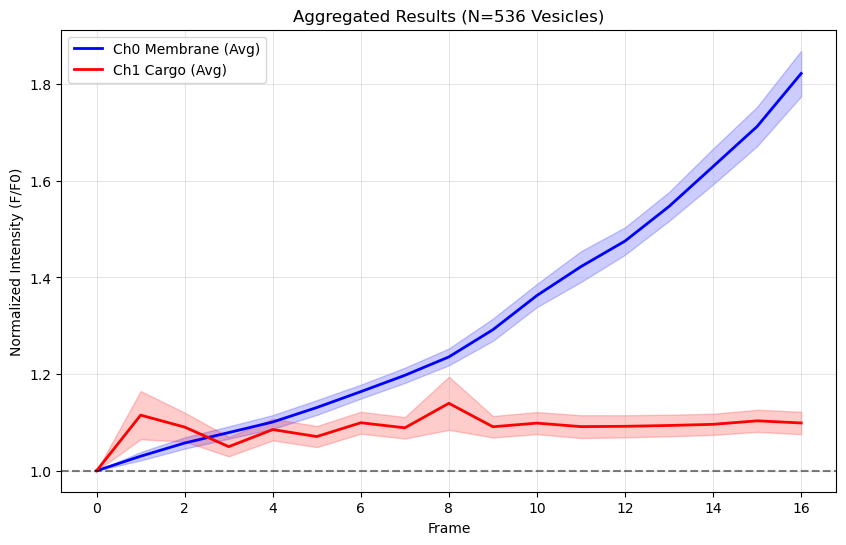

In [5]:
stats = master_df.groupby('FrameId').agg({
    'Norm0': ['mean', 'sem', 'count'],
    'Norm1': ['mean', 'sem', 'count']
})
stats.columns = ['_'.join(col).strip() for col in stats.columns.values]
stats.to_csv(os.path.join(INPUT_FOLDER, "Summary_Statistics.csv"))

plt.figure(figsize=(10, 6))
for ch, color, label in [('Norm0', 'blue', 'Ch0 Membrane'), ('Norm1', 'red', 'Ch1 Cargo')]:
    plt.plot(stats.index, stats[f'{ch}_mean'], color=color, label=f'{label} (Avg)', lw=2)
    plt.fill_between(stats.index, stats[f'{ch}_mean'] - stats[f'{ch}_sem'], 
                     stats[f'{ch}_mean'] + stats[f'{ch}_sem'], color=color, alpha=0.2)

plt.axhline(1.0, color='black', linestyle='--', alpha=0.5)
plt.title(f'Aggregated Results (N={int(stats["Norm0_count"].max())} Vesicles)')
plt.xlabel('Frame')
plt.ylabel('Normalized Intensity (F/F0)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(INPUT_FOLDER, "Final_Aggregated_Plot.png"))
plt.show()